/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/envs/registration.py:481: UserWarning: WARN: The environment creator metadata doesn't include `render_modes`, contains: ['paper_link', 'paper_name', 'tags']
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.seed to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.seed` for environment variables or `env.get_wrapper_attr('seed')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.new_trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.new_trial` for environment variables or `env.get_wrapper_attr('new_trial')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/

findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


...

findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


findfont: Font family 'Noto Sans' not found.


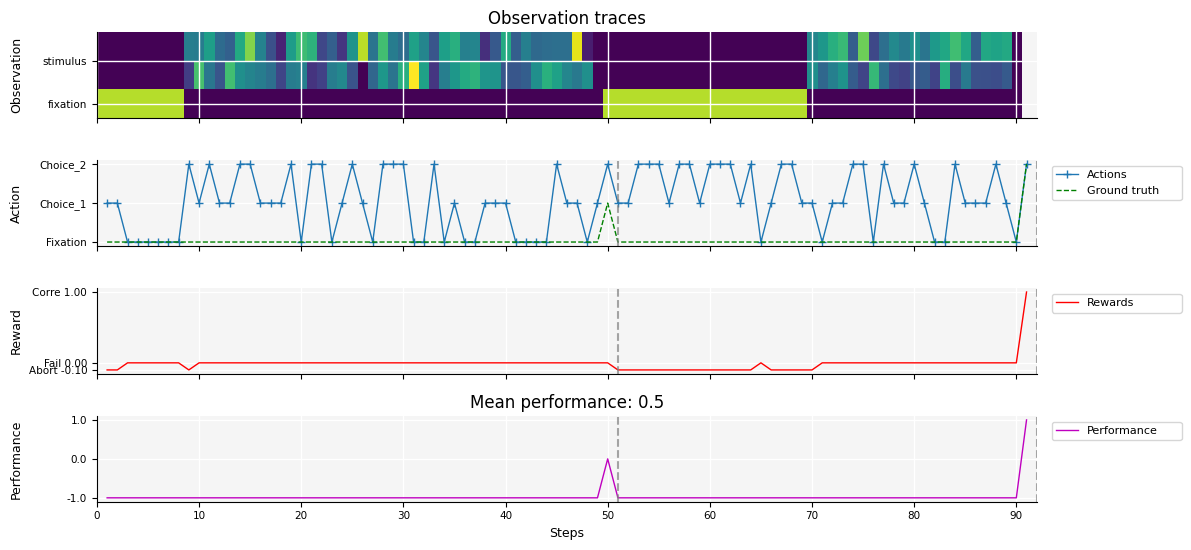

In [1]:
""" Defining a perceptual decision making task (2 choices) """
# import the task from the neurogym library
import neurogym as ngym 

# Environment
task = 'PerceptualDecisionMaking-v0'
timing = {
    'fixation': ('choice', (50, 100, 200, 400)), 
    'stimulus': ('choice', (100, 200, 400, 800)),
}
kwargs = {'dt': 20, 'timing': timing} 
seq_len = 100 

# Make supervised dataset
dataset = ngym.Dataset(task, env_kwargs=kwargs, batch_size=16, # 16 trials
                       seq_len=seq_len)

# A sample environment from dataset
env = dataset.env
# Visualize the environment with 2 sample trials
_ = ngym.utils.plot_env(env, num_trials=2) 

# Network input and output size
input_size = env.observation_space.shape[0] # 3: fixation - 0, stimulus 1 and 2
output_size = env.action_space.n # 3

In [2]:
import torch
import torch.nn as nn 
from torch.nn import init 
from torch.nn import functional as F 
import math
import numpy as np

""" Construct RNN without biological constrain """
class RecLinear(nn.Module): 
    def __init__(self, hidden_size, bias=False): # bias (h2h) is True biologically, but for W recovery, False might be better
        super().__init__() 
        self.hidden_size = hidden_size
        self.weight = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        
        mask = torch.ones(hidden_size, hidden_size)
        mask.fill_diagonal_(0) # mask the diagonal with 0, so even without dale's law, self-input is not acceptable 
        self.register_buffer("mask", mask)
        
        if bias:
            self.bias = nn.Parameter(torch.Tensor(hidden_size))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self): 
        init.kaiming_uniform_(self.weight, a=math.sqrt(5)) 
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight) 
            bound = 1 / math.sqrt(fan_in) 
            init.uniform_(self.bias, -bound, bound)

    def effective_weight(self):
        return self.weight * self.mask # has effective weight (diagonal masked)

    def forward(self, input):
        return F.linear(input, self.effective_weight(), self.bias) # input here means previous (t-1) hidden activity
    
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, dt=None, sigma_rec=0, **kwargs):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = 1 
        self.tau = 100 

        if dt is None:
            alpha = 1 
        else:
            alpha = dt / self.tau
        self.alpha = alpha
        self.oneminusalpha = 1 - alpha
        self._sigma_rec = np.sqrt(2 * alpha) * sigma_rec 
        self.input2h = nn.Linear(input_size, hidden_size)
        self.h2h = RecLinear(hidden_size)

    def init_hidden(self, input):
        batch_size = input.shape[1]
        state = torch.zeros(batch_size, self.hidden_size).to(input.device)
        output = torch.zeros(batch_size, self.hidden_size).to(input.device)
        return state, output

    def recurrence(self, input, hidden): 
        state, output = hidden
        total_input = self.input2h(input) + self.h2h(output)
        state = state * self.oneminusalpha + total_input * self.alpha
        state += self._sigma_rec * torch.randn_like(state)
        output = torch.relu(state)
        return state, output

    def forward(self, input, hidden=None): 
        if hidden is None:
            hidden = self.init_hidden(input)
        outputs = []
        for i in range(input.size(0)):
            hidden = self.recurrence(input[i], hidden)
            outputs.append(hidden[1])
        outputs = torch.stack(outputs, dim=0)
        return outputs, hidden
    
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, **kwargs):
        super().__init__()
        self.rnn = RNN(input_size, hidden_size, **kwargs)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        rnn_activity, _ = self.rnn(x)
        out = self.fc(rnn_activity)
        return out, rnn_activity

In [3]:
""" Train the RNN """
hidden_size = 50
net = Net(input_size=input_size, 
          hidden_size=hidden_size, 
          output_size=output_size, 
          dt=env.dt, 
          sigma_rec=0)
print(net)

import torch.optim as optim 
optimizer = optim.Adam(net.parameters(), lr=0.001) 
criterion = nn.CrossEntropyLoss() # minimizing loss: compare p^​(y) with y; L = -log p(correct); input is number of sample * number of class
running_loss = 0
running_acc = 0
print_step = 200 #
for i in range(5000): # 5000 times parameter update
    inputs, labels = dataset() # inputs = 100*16*3, labels = correct answer (100*16)
    inputs = torch.from_numpy(inputs).type(torch.float) # numpy array to torch tensor
    labels = torch.from_numpy(labels.flatten()).type(torch.long) # labels = 1600 * 1, all integers

    optimizer.zero_grad() 
    
    output, activity = net(inputs) # inputs = x (forward function in Net)
    output = output.view(-1, output_size) # reshape into 1600*3
    
    loss = criterion(output, labels) 
    loss.backward() 
    
    optimizer.step() 

    running_loss += loss.item() # total loss from the rnn
    if i % print_step == (print_step - 1): # print the loss every print_step (update) by mod == 199
        running_loss /= print_step 
        print('Step {}, Loss {:0.4f}'.format(i+1, running_loss))
        running_loss = 0 

/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.dt to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.dt` for environment variables or `env.get_wrapper_attr('dt')` that will search the reminding wrappers.
  logger.warn(


Net(
  (rnn): RNN(
    (input2h): Linear(in_features=3, out_features=50, bias=True)
    (h2h): RecLinear()
  )
  (fc): Linear(in_features=50, out_features=3, bias=True)
)


/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.new_trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.new_trial` for environment variables or `env.get_wrapper_attr('new_trial')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.ob to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.ob` for environment variables or `env.get_wrapper_attr('ob')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.gt to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.gt` for environment variables or `env.get

Step 200, Loss 0.5023


Step 400, Loss 0.3118


...

Step 4200, Loss 0.0689


Step 4400, Loss 0.0689


Step 4600, Loss 0.0685


Step 4800, Loss 0.0681


Step 5000, Loss 0.0664


(50, 50)
(50, 3)
(3, 50)


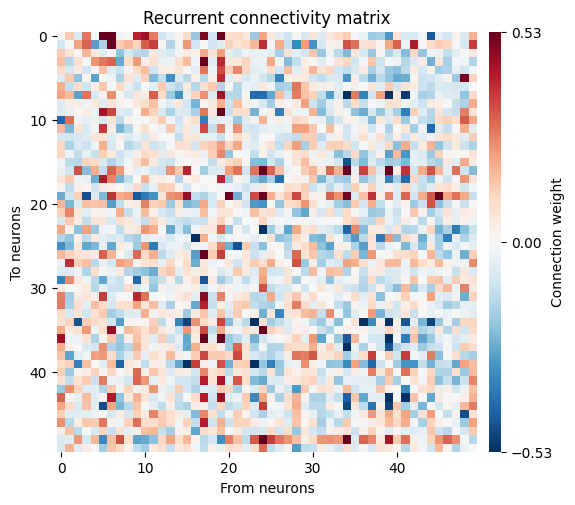

In [4]:
""" Visualize Matrices of RNN without constrain """
W_rec = net.rnn.h2h.effective_weight().detach().numpy()
W_in = net.rnn.input2h.weight.detach().numpy()
W_out = net.fc.weight.detach().numpy()
print(W_rec.shape)
print(W_in.shape)
print(W_out.shape)

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
n_neuron = W_rec.shape[0]
# color scale
wlim = np.percentile(np.abs(W_rec), 99)
wlim = int(wlim * 100) / 100

fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.7, 0.7])
im = ax.imshow(
    W_rec,
    cmap='RdBu_r',
    vmin=-wlim,
    vmax=wlim,
    extent=(-0.5, n_neuron - 0.5,
            n_neuron - 0.5, -0.5),
    interpolation='nearest'
)
plt.xlabel('From neurons')
plt.ylabel('To neurons')
plt.title('Recurrent connectivity matrix')
for loc in ['left', 'right', 'top', 'bottom']:
    ax.spines[loc].set_visible(False)
cax = fig.add_axes([0.82, 0.1, 0.02, 0.7])
cb = plt.colorbar(
    im,
    cax=cax,
    ticks=[-wlim, 0, wlim]
)
cb.set_label('Connection weight', labelpad=-1)
cb.outline.set_linewidth(0)

plt.show()

In [5]:
""" Free the teacher RNN and do the sanity check to see if it can recover the result """
inputs, labels = dataset()
inputs = torch.from_numpy(inputs).float()

with torch.no_grad():       
    _, r1 = net(inputs)
    _, r2 = net(inputs)

mse = torch.mean((r1 - r2) ** 2)
print("MSE:", mse.item())

MSE: 0.0


In [6]:
""" Freeze the teacher RNN and generate data (inputs = trial time*1*3) """
# make sure to freeze the teacher rnn even there is no updating procedure
for p in net.parameters():
    p.requires_grad = False
# record teacher rnn for training
teacher_rs = [] # for student B and D
teacher_outputs = [] # for student C
teacher_labels = [] # for student A
teacher_inputs = []
# save information for analysis
trial_infos = {}
activity_dict = {}
stim_activity = [[], []]  # save response for ground-truth 0 and 1
# keep the input stimulus and fixation time constant
env.reset() 
env.timing.update({'fixation': ('constant', 500),
                   'stimulus': ('constant', 500)})

num_trial = 500 # use 500 new trials
for i in range(num_trial):
    env.new_trial()
    ob, gt = env.ob, env.gt # get input and ground truth (labels/gt)
    inputs = torch.from_numpy(ob[:, np.newaxis, :]).type(torch.float) # rnn requires input structure as (time,batch,input), so we add np.newaxis as batch=1
    with torch.no_grad(): # do not train RNN, only generate data
        output, activity = net(inputs) # output is the logits at every timestep, activity is r
    teacher_inputs.append(inputs.cpu().numpy()) # teacher input is before bias
    teacher_outputs.append(output.detach().cpu().numpy()) # decision logits calculated by r
    teacher_rs.append(activity.detach().cpu().numpy()) # r

    # Compute performance
    output = output.detach().numpy()
    choice = np.argmax(output[-1, 0, :])
    correct = choice == gt[-1]
    trial_info = env.trial.copy()
    trial_info.update({'correct': correct, 'choice': choice}) # add accuracy and choice to trial information
    trial_infos[i] = trial_info

    labels = torch.from_numpy(gt.flatten()).long()
    teacher_labels.append(labels.cpu().numpy()) # save labels

    activity = activity[:, 0, :].detach().numpy()
    activity_dict[i] = activity # save activity (no batch) for pca/plotting
    # Compute stimulus selectivity for all units
    # Compute each neuron's response in trials where ground_truth=0 and 1 respectively
    activity = activity[env.start_ind['stimulus']: env.end_ind['stimulus']]
    stim_activity[env.trial['ground_truth']].append(activity)

teacher_accuracy = np.mean([val['correct'] for val in trial_infos.values()])
print('Average performance', teacher_accuracy)

/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.timing to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.timing` for environment variables or `env.get_wrapper_attr('timing')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.trial to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.trial` for environment variables or `env.get_wrapper_attr('trial')` that will search the reminding wrappers.
  logger.warn(
/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.start_ind to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.start_ind` for environment variabl

Average performance 0.852


Text(0, 0.5, 'Activity')

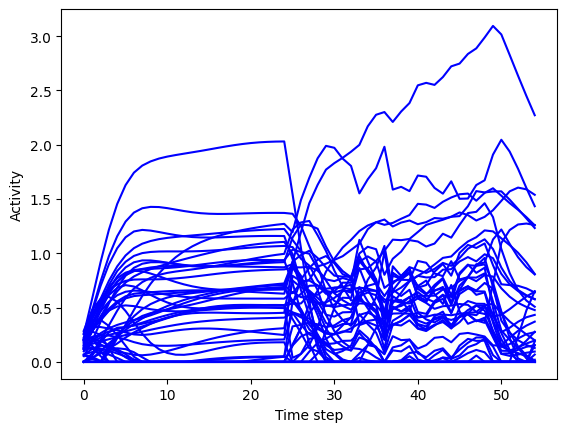

In [7]:
""" Plot teacher RNN neural activity from sample trials """
trial = 2

plt.figure()
_ = plt.plot(activity_dict[trial][:, :], color='blue')
plt.xlabel('Time step')
plt.ylabel('Activity')

In [8]:
# Student RNN and teacher RNN have the same structure
""" Train the student RNN by learning teacher's labels """
# Parameters updated during training (student_A)

# input -> hidden layer
# rnn.input2h.weight : trainable
# rnn.input2h.bias   : trainable

# recurrent hidden -> hidden layer
# rnn.h2h.weight     : trainable
# rnn.h2h.bias       : None (bias=False, therefore not trainable)

# hidden -> output layer
# fc.weight          : trainable
# fc.bias            : trainable

# recurrent noise
# sigma_rec = 0 -> deterministic RNN (no recurrent noise)

student_A = Net(input_size, hidden_size, output_size, dt=env.dt, sigma_rec=0) # used to be 0.15
optimizer_A = optim.Adam(student_A.parameters(), lr=0.001)
criterion_A = nn.CrossEntropyLoss()
running_loss_A = 0
print_step = 200
step = 0
for epoch in range(20): 
    indices = np.random.permutation(len(teacher_inputs)) # length of teacher_inputs = 500
    for idx in indices: # shuffled the inputs and select one each time to learn
        inputs = torch.from_numpy(teacher_inputs[idx]).float()
        labels = torch.from_numpy(teacher_labels[idx]).long()

        optimizer_A.zero_grad()
        output_A, activity_A = student_A(inputs)
        output_A = output_A.view(-1, output_size) # reshape into (trial_time, 3)
        loss_A = criterion_A(output_A, labels)
        loss_A.backward()
        optimizer_A.step()
        running_loss_A += loss_A.item()

        step += 1
        if step % print_step == 0:
            running_loss_A /= print_step
            print('Step {}, Loss {:0.4f}'.format(step, running_loss_A))
            running_loss_A = 0

/opt/anaconda3/envs/neurogym/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.dt to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.dt` for environment variables or `env.get_wrapper_attr('dt')` that will search the reminding wrappers.
  logger.warn(


Step 200, Loss 0.2787


Step 400, Loss 0.1102


Step 600, Loss 0.0941


Step 800, Loss 0.0867


...

Step 9200, Loss 0.0402


Step 9400, Loss 0.0415


Step 9600, Loss 0.0420


Step 9800, Loss 0.0422


Step 10000, Loss 0.0407


In [9]:
""" Train the student RNN by learning the teacher's hidden activity r """
# Parameters updated during training (student_B)

# input -> hidden layer
# rnn.input2h.weight : trainable
# rnn.input2h.bias   : trainable

# recurrent hidden -> hidden layer
# rnn.h2h.weight     : trainable
# rnn.h2h.bias       : None (bias=False, therefore not trainable)

# hidden -> output layer
# fc.weight          : not updated (output not used in loss)
# fc.bias            : not updated (output not used in loss)

# recurrent noise
# sigma_rec = 0 -> deterministic RNN (no recurrent noise)

student_B = Net(input_size, hidden_size, output_size, dt=env.dt, sigma_rec=0) # used to be 0.15
optimizer_B = optim.Adam(student_B.parameters(), lr=0.001)
criterion_B = nn.MSELoss() # Mean squared error = loss
running_loss_B = 0
print_step = 200
step = 0
for epoch in range(20):
    indices = np.random.permutation(len(teacher_inputs)) # 500
    for idx in indices:
        inputs = torch.from_numpy(teacher_inputs[idx]).float()
        target_r = torch.from_numpy(teacher_rs[idx]).float()

        optimizer_B.zero_grad()
        output_B, activity_B = student_B(inputs)
        loss_B = criterion_B(activity_B, target_r)
        loss_B.backward()
        optimizer_B.step()

        running_loss_B += loss_B.item() 
        step += 1
        if step % print_step == 0:
            running_loss_B /= print_step
            print('Step {}, Loss {:0.4f}'.format(step, running_loss_B))
            running_loss_B = 0

Step 200, Loss 0.1625


Step 400, Loss 0.1105


Step 600, Loss 0.0965


Step 800, Loss 0.0823


Step 1000, Loss 0.0583


...

Step 9200, Loss 0.0468


Step 9400, Loss 0.0463


Step 9600, Loss 0.0456


Step 9800, Loss 0.0468


Step 10000, Loss 0.0461


In [10]:
""" Train student RNN by learning teacher's final-step behavior probability distribution """
# Parameters updated during training (student_C)

# input -> hidden layer
# rnn.input2h.weight : trainable
# rnn.input2h.bias   : trainable

# recurrent hidden -> hidden layer
# rnn.h2h.weight     : trainable
# rnn.h2h.bias       : None (bias=False, therefore not trainable)

# hidden -> output layer
# fc.weight          : trainable
# fc.bias            : trainable

# recurrent noise
# sigma_rec = 0 -> deterministic RNN (no recurrent noise)

student_C = Net(input_size, hidden_size, output_size, dt=env.dt, sigma_rec=0) # used to be 0.15
optimizer_C = optim.Adam(student_C.parameters(), lr=0.001)
criterion_C = nn.KLDivLoss(reduction='batchmean') # learn the probability distribution

running_loss_C = 0
print_step = 200
step = 0
temperature = 1.0
for epoch in range(20):
    indices = np.random.permutation(len(teacher_inputs))

    for idx in indices:
        inputs = torch.from_numpy(teacher_inputs[idx]).float()
        target_output = torch.from_numpy(teacher_outputs[idx]).float()
        optimizer_C.zero_grad()
        output_C, activity_C = student_C(inputs)
        # only learn the last step
        teacher_prob = torch.softmax(target_output[-1, 0, :] / temperature, dim=-1) # target has to be probability
        student_logprob = torch.log_softmax(output_C[-1, 0, :] / temperature, dim=-1) # input has to be log probability
        loss_C = criterion_C(student_logprob, teacher_prob)
        loss_C.backward()
        optimizer_C.step()

        running_loss_C += loss_C.item()
        step += 1
        if step % print_step == 0:
            running_loss_C /= print_step
            print('Step {}, Loss {:0.4f}'.format(step, running_loss_C))
            running_loss_C = 0

Step 200, Loss 0.1371


Step 400, Loss 0.0318


Step 600, Loss 0.0202


Step 800, Loss 0.0196


Step 1000, Loss 0.0066


...

Step 9200, Loss 0.0012


Step 9400, Loss 0.0014


Step 9600, Loss 0.0018


Step 9800, Loss 0.0016


Step 10000, Loss 0.0006


In [11]:
""" Train the student network by learning r but using teacher's input->hidden layer """
# Parameters updated during training (student_D)

# input -> hidden layer
# rnn.input2h.weight : not trainable (same as teacher)
# rnn.input2h.bias   : not trainable (same as teacher)

# recurrent hidden -> hidden layer
# rnn.h2h.weight     : trainable
# rnn.h2h.bias       : None (bias=False, therefore not trainable)

# hidden -> output layer
# fc.weight          : not updated (output not used in loss)
# fc.bias            : not updated (output not used in loss)

# recurrent noise
# sigma_rec = 0 -> deterministic RNN (no recurrent noise)
def train_student_D(epochs=20, lr=0.001, name="D"):
    student = Net(input_size=input_size,
                  hidden_size=hidden_size,
                  output_size=output_size,
                  dt=env.dt,
                  sigma_rec=0)
    
    # Copy teacher (net) input -> hidden layer
    student.rnn.input2h.load_state_dict(net.rnn.input2h.state_dict())

    # Freeze everything first
    for p in student.parameters():
        p.requires_grad = False
    
    # Only train recurrent weight; optionally train recurrent bias (bias is NOT noise)
    student.rnn.h2h.weight.requires_grad = True
    if student.rnn.h2h.bias is not None: # since in EIRecLinear, bias = False (teacher bias equal to None), so the sentence is always not satisfied
        student.rnn.h2h.bias.requires_grad = True

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, student.parameters()), lr=lr)
    criterion = nn.MSELoss()

    running_loss = 0
    print_step = 200
    step = 0
    last_loss = None

    for epoch in range(epochs):
        indices = np.random.permutation(len(teacher_inputs))

        for idx in indices:
            inputs = torch.from_numpy(teacher_inputs[idx]).float()
            target_r = torch.from_numpy(teacher_rs[idx]).float()

            optimizer.zero_grad()
            output, activity = student(inputs)
            loss = criterion(activity, target_r)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            last_loss = loss.item()
            step += 1

            if step % print_step == 0:
                running_loss /= print_step
                print(f'Step {step}, Loss {running_loss:.4f}')
                running_loss = 0
    return student, last_loss

# student D has the same input->hidden layer as the teacher, and fit hidden layer weight only 
student_D, loss_D = train_student_D(epochs=20, lr=0.001, name="D activity-trained weight-only")

Step 200, Loss 0.1097


Step 400, Loss 0.0323


Step 600, Loss 0.0254


Step 800, Loss 0.0223


Step 1000, Loss 0.0219


...

Step 9200, Loss 0.0188


Step 9400, Loss 0.0178


Step 9600, Loss 0.0185


Step 9800, Loss 0.0188


Step 10000, Loss 0.0179


In [12]:
""" Evaluation """
def get_recurrent_weight(model):
    if hasattr(model.rnn.h2h, "effective_weight"):
        return model.rnn.h2h.effective_weight().detach().numpy()
    return model.rnn.h2h.weight.detach().numpy() 

def weight_corr(W_teacher, W_student):
    corr_signed = np.corrcoef(W_teacher.flatten(), W_student.flatten())[0, 1]
    corr_abs = np.corrcoef(np.abs(W_teacher).flatten(), np.abs(W_student).flatten())[0, 1]
    return corr_signed, corr_abs

def evaluate_activity_mse(student): # compare teacher r and student r
    criterion = nn.MSELoss()
    total_loss = 0
    n = 0
    with torch.no_grad():
        indices = range(len(teacher_inputs))
        for idx in indices:
            inputs = torch.from_numpy(teacher_inputs[idx]).float()
            target_r = torch.from_numpy(teacher_rs[idx]).float()
            _, activity = student(inputs)
            loss = criterion(activity, target_r)
            total_loss += loss.item()
            n += 1
    return total_loss / n

def evaluate_accuracy(student):
    correct_list = []
    with torch.no_grad():
        indices = range(len(teacher_inputs))
        for idx in indices:
            inputs = torch.from_numpy(teacher_inputs[idx]).float()
            labels = torch.from_numpy(teacher_labels[idx]).long()
            output, _ = student(inputs)
            # final-step choice
            choice = torch.argmax(output[-1, 0, :]).item()
            correct = choice == labels[-1].item()
            correct_list.append(correct)
    return np.mean(correct_list)

students_for_eval = [
    ("A label-trained", student_A),
    ("B activity-trained", student_B),
    ("C final-probability-trained", student_C),
    ("D activity-trained weight-only", student_D),
]
W_teacher = get_recurrent_weight(net)

eval_results = []
for name, student in students_for_eval:
    W_student = get_recurrent_weight(student)
    corr_signed, corr_abs = weight_corr(W_teacher, W_student)
    mean_mse = evaluate_activity_mse(student)
    mean_acc = evaluate_accuracy(student)
    eval_results.append({
        "name": name,
        "activity_mse": mean_mse,
        "accuracy": mean_acc,
        "signed_corr": corr_signed,
        "abs_corr": corr_abs,
        "diagonal_zero": np.allclose(np.diag(W_student), 0),
    })
for result in eval_results:
    print(result["name"])
    print("  activity MSE:", result["activity_mse"])
    print("  accuracy:", result["accuracy"])
    print("  signed W corr:", result["signed_corr"])
    print("  abs W corr:", result["abs_corr"])
    print("  diagonal zero:", result["diagonal_zero"])

A label-trained
  activity MSE: 0.7515105125904084
  accuracy: 0.842
  signed W corr: -0.002038227514988573
  abs W corr: 0.039882539602886895
  diagonal zero: True
B activity-trained
  activity MSE: 0.04619227340072393
  accuracy: 0.354
  signed W corr: 0.16830511666592848
  abs W corr: 0.10487204097606445
  diagonal zero: True
C final-probability-trained
  activity MSE: 0.34860281020402906
  accuracy: 0.862
  signed W corr: -0.013740882535614384
  abs W corr: 0.006190741178430699
  diagonal zero: True
D activity-trained weight-only
  activity MSE: 0.018341293232515453
  accuracy: 0.53
  signed W corr: 0.6013353765701287
  abs W corr: 0.48324974462075165
  diagonal zero: True


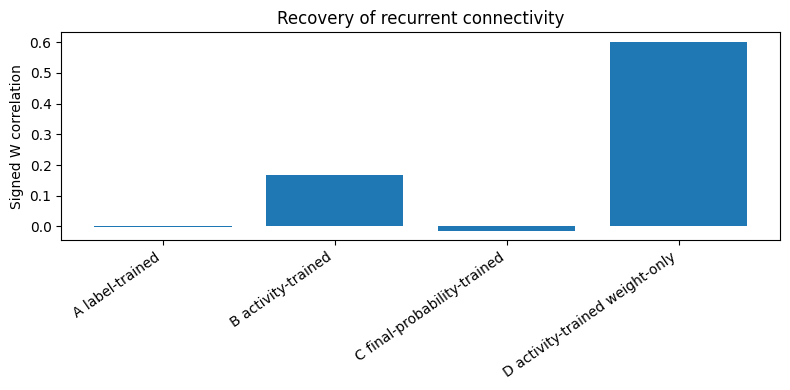

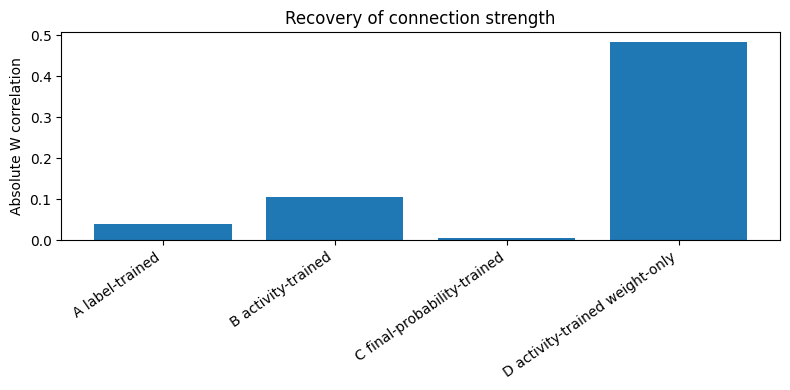

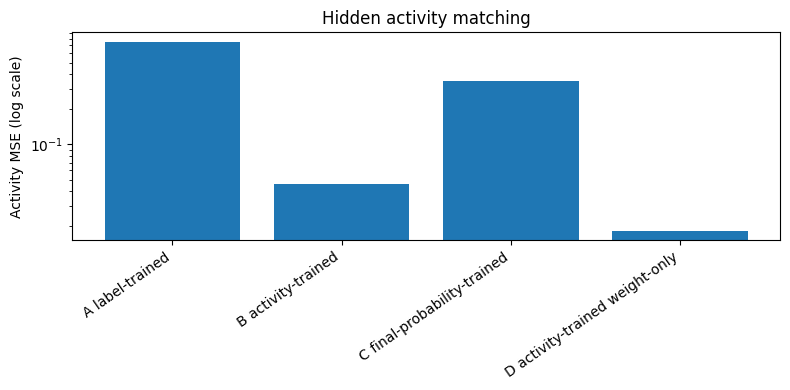

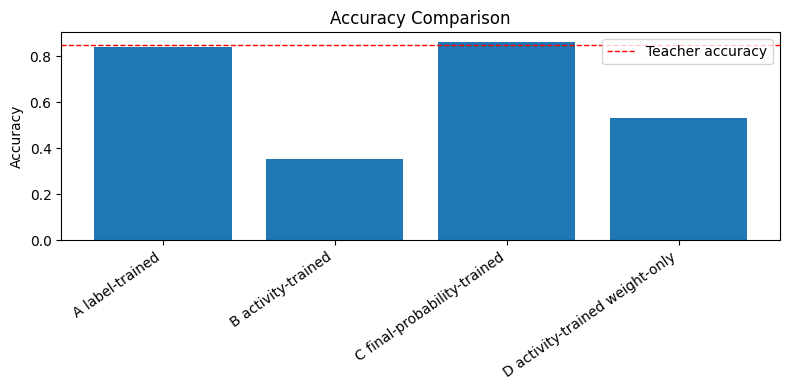

In [13]:
""" Summary plots """
names = [r["name"] for r in eval_results]
activity_mse = [r["activity_mse"] for r in eval_results]
signed_corr = [r["signed_corr"] for r in eval_results]
abs_corr = [r["abs_corr"] for r in eval_results]
accuracy = [r["accuracy"] for r in eval_results]

plt.figure(figsize=(8, 4))
plt.bar(names, signed_corr)
plt.ylabel("Signed W correlation")
plt.xticks(rotation=35, ha="right")
plt.title("Recovery of recurrent connectivity")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(names, abs_corr)
plt.ylabel("Absolute W correlation")
plt.xticks(rotation=35, ha="right")
plt.title("Recovery of connection strength")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(names, activity_mse)
plt.yscale("log")
plt.ylabel("Activity MSE (log scale)")
plt.xticks(rotation=35, ha="right")
plt.title("Hidden activity matching")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(names, accuracy)
plt.axhline(teacher_accuracy, linestyle='--', linewidth=1, color='r', label='Teacher accuracy')
plt.ylabel("Accuracy")
plt.xticks(rotation=35, ha="right")
plt.title("Accuracy Comparison")
plt.legend()
plt.tight_layout()
plt.show()


Explained variance ratio:
PC1: 0.5930627
PC2: 0.19329432
PC3: 0.114179164
Total: 0.9005362


Teacher PC1-3 explain: 0.09983045


Teacher PC1-3 explain: 0.82840616


Teacher PC1-3 explain: 0.13800462


Teacher PC1-3 explain: 0.8703935


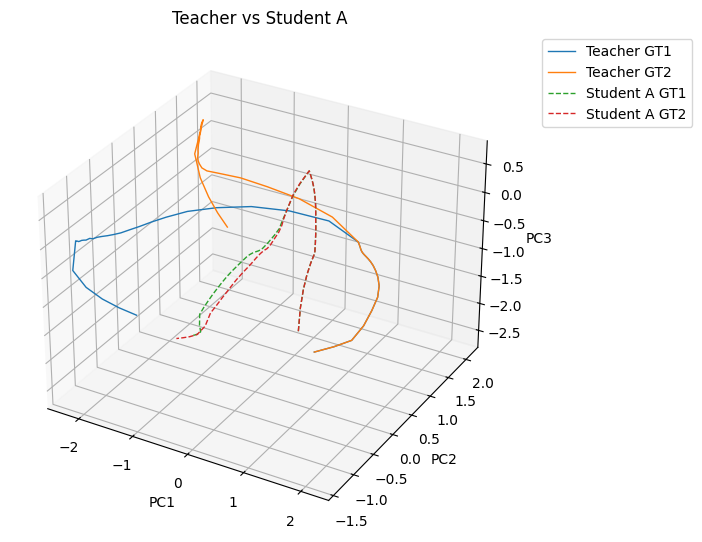

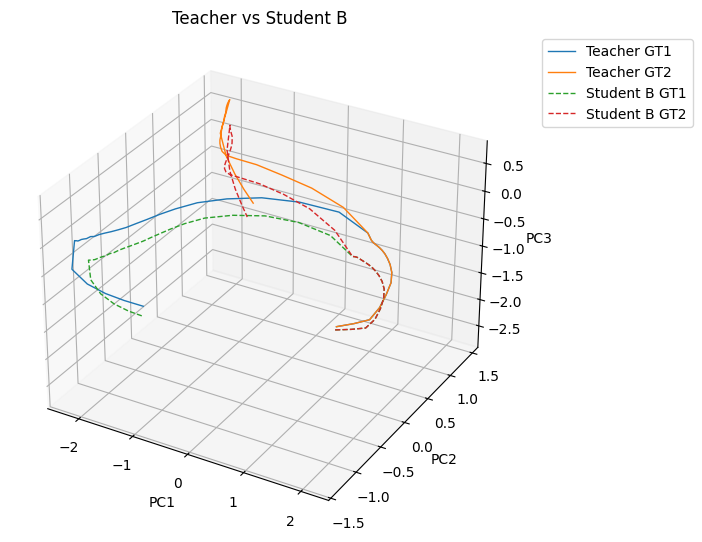

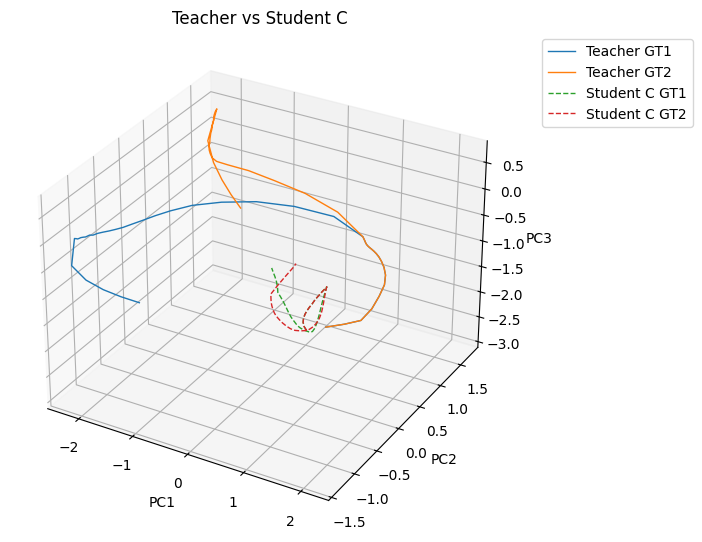

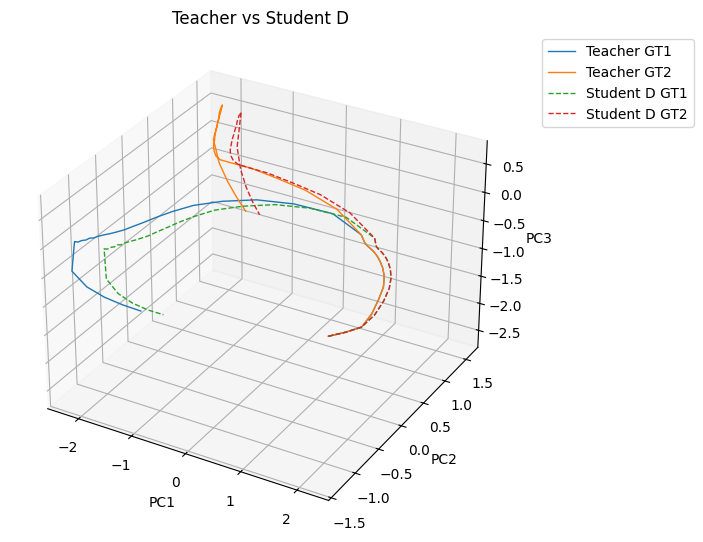

In [14]:
""" PCA comparison between teacher and students """
from sklearn.decomposition import PCA
# teacher activity
T = activity_dict[0].shape[0] # time of trial (55)
H = activity_dict[0].shape[1] # hidden size (50)
n_trial = len(activity_dict) # 500
teacher_activity = np.stack([activity_dict[i] for i in range(n_trial)], axis=0) # (n_trial, trial_time, hidden_size)
teacher_flat = teacher_activity.reshape(-1, H) # PCA require input with (sample=n_trial*trial_time, feature=neuron) 

# PCA on teacher
pca = PCA(n_components=3)
teacher_pca_flat = pca.fit_transform(teacher_flat) # -> (sample, 3), used to be 2
teacher_pca = teacher_pca_flat.reshape(n_trial, T, 3)
print("Explained variance ratio:")
print("PC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])
print("PC3:", pca.explained_variance_ratio_[2])
print("Total:", np.sum(pca.explained_variance_ratio_)) # explain about 90% of variance

# get student activity
def get_student_activity(student):
    student_activity = []
    with torch.no_grad():
        for idx in range(len(teacher_inputs)):
            inputs = torch.from_numpy(teacher_inputs[idx]).float()
            _, activity = student(inputs)
            activity = (activity[:, 0, :].detach().cpu().numpy())
            student_activity.append(activity)
    return np.stack(student_activity, axis=0)

# project student to teacher PCA space
def project_to_teacher_pca(student):
    student_activity = get_student_activity(student)
    student_flat = student_activity.reshape(-1, H)
    student_pca_flat = pca.transform(student_flat) # project onto 3 PCs of teacher
    student_pca = student_pca_flat.reshape(student_activity.shape[0], student_activity.shape[1], 3)
    # how much of student's variance can be explained by teacher's 3 PCs
    student_total_var = np.var(student_flat, axis=0).sum()
    student_pc_var = np.var(student_pca_flat, axis=0).sum()
    explained_ratio = (student_pc_var/student_total_var)
    print("Teacher PC1-3 explain:", explained_ratio)
    return student_pca, explained_ratio

student_A_pca, student_A_pca_overlap = project_to_teacher_pca(student_A)
student_B_pca, student_B_pca_overlap = project_to_teacher_pca(student_B)
student_C_pca, student_C_pca_overlap = project_to_teacher_pca(student_C)
student_D_pca, student_D_pca_overlap = project_to_teacher_pca(student_D)

# plot teacher vs one student
def plot_teacher_student_pca(student_pca, student_name): # average the outcome based on different ground truth
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(projection='3d')
    # separate by ground truth
    gt1_idx = []
    gt2_idx = []
    for i in range(n_trial):
        gt = teacher_labels[i][-1]
        if gt == 1:
            gt1_idx.append(i)
        else:
            gt2_idx.append(i)
    # mean trajectory
    teacher_mean_1 = np.mean(teacher_pca[gt1_idx], axis=0)
    teacher_mean_2 = np.mean(teacher_pca[gt2_idx], axis=0)

    student_mean_1 = np.mean(student_pca[gt1_idx], axis=0)
    student_mean_2 = np.mean(student_pca[gt2_idx], axis=0)

    ax.plot(teacher_mean_1[:,0], teacher_mean_1[:,1], teacher_mean_1[:,2], linewidth=1, label='Teacher GT1')
    ax.plot(teacher_mean_2[:,0], teacher_mean_2[:,1], teacher_mean_2[:,2], linewidth=1, label='Teacher GT2')
    ax.plot(student_mean_1[:,0], student_mean_1[:,1], student_mean_1[:,2], '--', linewidth=1, label=f'{student_name} GT1')
    ax.plot(student_mean_2[:,0], student_mean_2[:,1], student_mean_2[:,2], '--', linewidth=1, label=f'{student_name} GT2')

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(f'Teacher vs {student_name}')
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.subplots_adjust(right=0.75)
    plt.show()
    
plot_teacher_student_pca(student_A_pca, "Student A")
plot_teacher_student_pca(student_B_pca, "Student B")
plot_teacher_student_pca(student_C_pca, "Student C")
plot_teacher_student_pca(student_D_pca, "Student D") 

In [15]:
""" Save results """
import json
results = {
    # teacher PCA
    "pca_pc1": float(pca.explained_variance_ratio_[0]),
    "pca_pc2": float(pca.explained_variance_ratio_[1]),
    "pca_pc3": float(pca.explained_variance_ratio_[2]),
    "pca_total_3pc": float(np.sum(pca.explained_variance_ratio_[:3])),

    # student PCA overlap
    "A_pca_overlap": float(student_A_pca_overlap),
    "B_pca_overlap": float(student_B_pca_overlap),
    "C_pca_overlap": float(student_C_pca_overlap),
    "D_pca_overlap": float(student_D_pca_overlap),

    # accuracy
    "A_accuracy": float(eval_results[0]["accuracy"]),
    "B_accuracy": float(eval_results[1]["accuracy"]),
    "C_accuracy": float(eval_results[2]["accuracy"]),
    "D_accuracy": float(eval_results[3]["accuracy"]),

    # activity MSE
    "A_activity_mse": float(eval_results[0]["activity_mse"]),
    "B_activity_mse": float(eval_results[1]["activity_mse"]),
    "C_activity_mse": float(eval_results[2]["activity_mse"]),
    "D_activity_mse": float(eval_results[3]["activity_mse"]),

    # W correlation
    "A_signed_corr": float(eval_results[0]["signed_corr"]),
    "B_signed_corr": float(eval_results[1]["signed_corr"]),
    "C_signed_corr": float(eval_results[2]["signed_corr"]),
    "D_signed_corr": float(eval_results[3]["signed_corr"]),
}
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print("results saved")

results saved
